# Univariate forecasting with `pymc_forecast`

This notebook ports the upstream NumPyro univariate forecasting example to the PyMC API.
We forecast **weekly BART ridership** with a random-walk local level, annual Fourier
seasonality, and a Student-T likelihood, fit with variational inference and evaluated
with the continuous ranked probability score (CRPS).

The data is derived from the complete hourly BART origin-destination panel used by the
upstream example. All predictive results use `arviz.InferenceData`, and all time handling
uses labeled `xarray` coordinates.


## Prepare notebook


In [1]:
import logging
import os
from functools import partial

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    Forecaster,
    ForecastingModel,
    Horizon,
    backtest,
    build_model,
    eval_coverage,
    eval_crps,
    evaluate_forecast,
    fourier_features,
    predict,
    results_to_dataframe,
    time_series,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM
from pymc_forecast.datasets import load_bart_weekly

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

SEED = 42

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
NUM_STEPS = 300 if SMOKE_TEST else 20_000
NUM_SAMPLES = 50 if SMOKE_TEST else 1_000
BACKTEST_SAMPLES = 50 if SMOKE_TEST else 500

## Read data

We use the same data as the upstream notebook: total **weekly** BART ridership. The
package downloads and verifies the complete hourly origin-destination dataset, then sums
over station pairs and non-overlapping weeks before applying a log transform.


weekly observations: 469


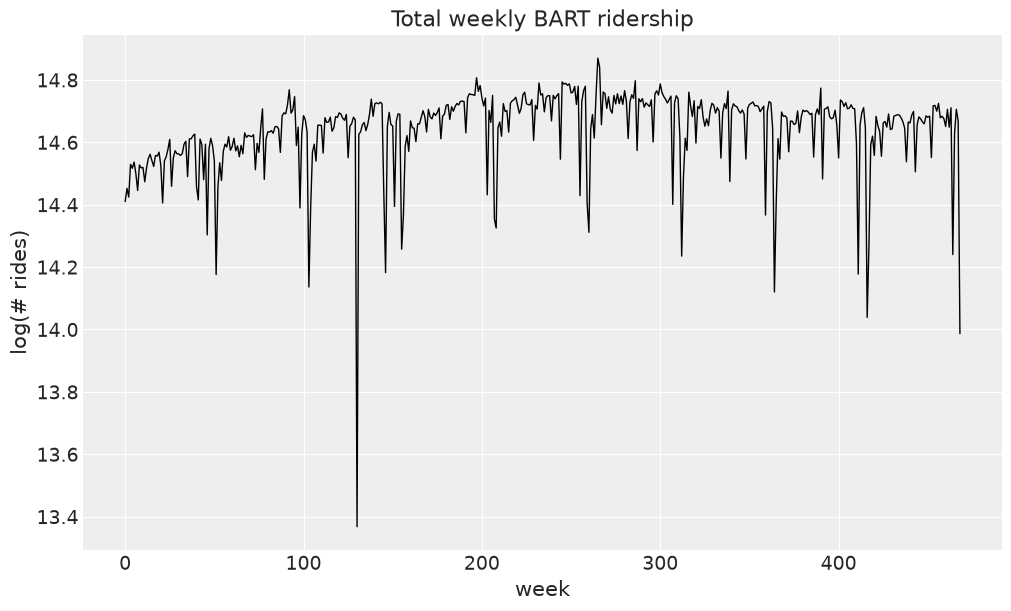

In [2]:
y = load_bart_weekly()
duration = y.sizes[TIME_DIM]
print("weekly observations:", duration)

fig, ax = plt.subplots()
ax.plot(y[TIME_DIM].values, y.values, color="black", lw=1)
ax.set(title="Total weekly BART ridership", xlabel="week", ylabel="log(# rides)")
plt.show()

## Train-test split

Hold out the final 52 weeks, matching the one-year forecasting horizon in the upstream
example. The integer week coordinates are preserved in the predictive groups.


train: 417 test: 52


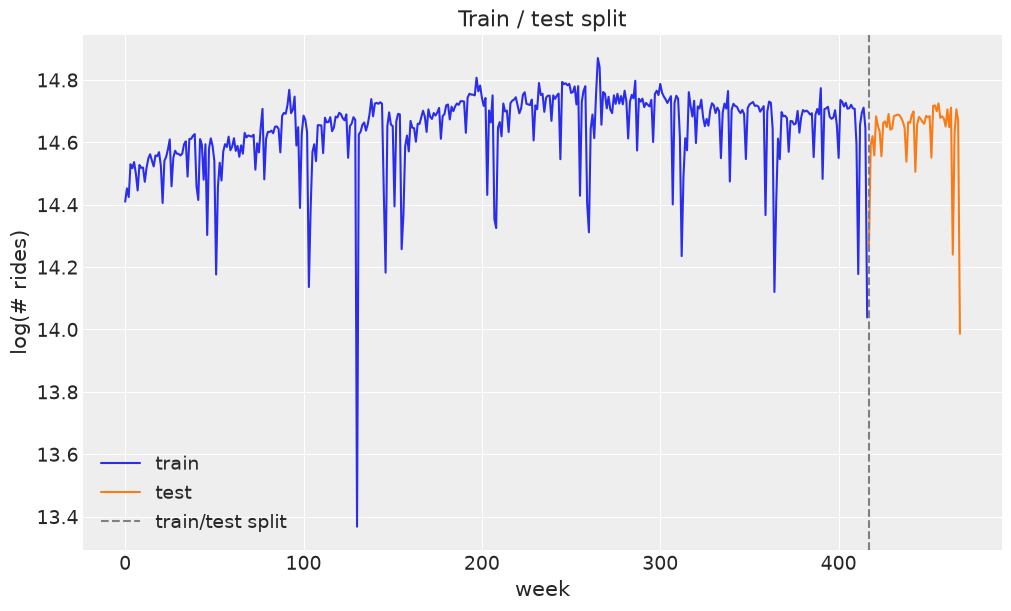

In [3]:
TEST_WINDOW = 52
T1 = duration - TEST_WINDOW

y_train = y.isel({TIME_DIM: slice(None, T1)})
y_test = y.isel({TIME_DIM: slice(T1, None)})
print("train:", y_train.sizes[TIME_DIM], "test:", y_test.sizes[TIME_DIM])

fig, ax = plt.subplots()
ax.plot(y_train[TIME_DIM].values, y_train.values, color="C0", label="train")
ax.plot(y_test[TIME_DIM].values, y_test.values, color="C1", label="test")
ax.axvline(y_test[TIME_DIM].values[0], color="gray", ls="--", label="train/test split")
ax.legend(loc="lower left")
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)")
plt.show()

## Seasonal features

The BART series is weekly, so the seasonal design uses a 365.25 / 7 week period and 26
Fourier harmonics, matching the upstream example. Feature and observation coordinates
remain aligned by week.


covariates: Frozen({'time': 469, 'covariate': 52})


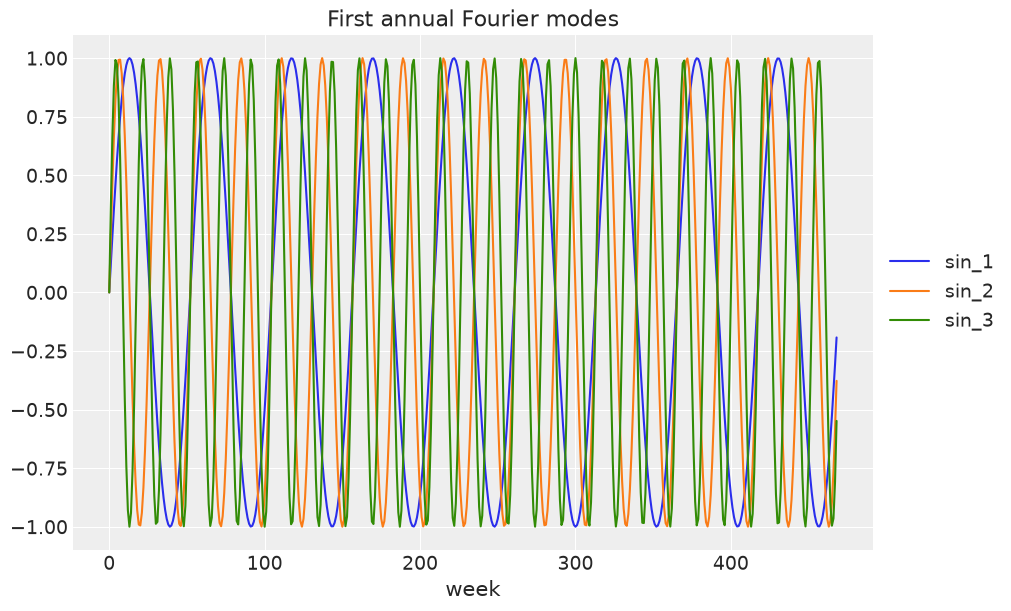

In [4]:
NUM_TERMS = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=NUM_TERMS)
covariates = covariates.rename({"fourier": "covariate"})
covariates_train = covariates.isel({TIME_DIM: slice(None, T1)})
print("covariates:", covariates.sizes)

fig, ax = plt.subplots()
for name in covariates["covariate"].values[:3]:
    ax.plot(covariates[TIME_DIM].values, covariates.sel(covariate=name).values, label=name)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="First annual Fourier modes", xlabel="week")
plt.show()

## Model specification

The mean has three pieces: a global intercept, a random-walk local level, and a linear
regression on Fourier features. The forecast horizon is represented by separate
`*_future` variables through `time_series`, so fitting and forecasting use one model body.
The random walk is non-centered for stable PyMC variational inference while retaining the
upstream model's priors.


In [5]:
class LocalLevelSeasonal(ForecastingModel):
    """Local level + Fourier regression with Student-T observations."""

    def model(self, h: Horizon, covariates: xr.DataArray) -> None:
        bias = pm.Normal("bias", 0.0, 10.0)
        weight = pm.Normal("weight", 0.0, 0.1, dims="covariate")
        drift_scale = pm.LogNormal("drift_scale", -20.0, 5.0, initval=0.01)
        nu = pm.Gamma("nu", alpha=10.0, beta=2.0)
        sigma = pm.LogNormal("sigma", -5.0, 5.0, initval=0.05)

        drift_raw = self.time_series(
            "drift_raw",
            lambda name, dims: pm.Normal(name, 0.0, 1.0, dims=dims),
        )
        level = pt.cumsum(drift_raw * drift_scale)
        regression = pt.dot(covariates.values, weight)
        prediction = bias + level + regression

        self.predict(
            lambda name, mu, dims, observed: pm.StudentT(
                name,
                nu=nu,
                mu=mu,
                sigma=sigma,
                dims=dims,
                observed=observed,
            ),
            prediction,
        )


model = LocalLevelSeasonal()
train_model = build_model(model, y_train, covariates_train)
train_model

       bias ~ Normal(0, 10)
     weight ~ Normal(0, 0.1)
drift_scale ~ LogNormal(-20, 5)
         nu ~ Gamma(10, <constant>)
      sigma ~ LogNormal(-5, 5)
  drift_raw ~ Normal(0, 1)
        obs ~ StudentT(nu, f(bias, weight, drift_raw, drift_scale), sigma)

## Plot helper


In [6]:
def attach_constant_data(idata, *, name: str, values: np.ndarray, dim: str) -> None:
    """Add an ArviZ constant-data group used by plot_lm."""
    idata["constant_data"] = xr.Dataset(
        {name: (dim, np.asarray(values, dtype=float))},
        coords={dim: idata["observed_data"][dim].values},
    )


def lm_idata_from_forecast(
    samples: xr.DataArray,
    truth: xr.DataArray,
    *,
    x_name: str,
    x_values: np.ndarray,
):
    """Represent held-out forecasts as an ArviZ posterior predictive container."""
    return az.from_dict(
        {
            "posterior_predictive": {"obs": samples.values},
            "observed_data": {"obs": truth.values},
            "constant_data": {x_name: np.asarray(x_values, dtype=float)},
        },
        coords={TIME_DIM: truth[FUTURE_DIM].values},
        dims={"obs": [TIME_DIM], x_name: [TIME_DIM]},
    )

## Prior predictive checks


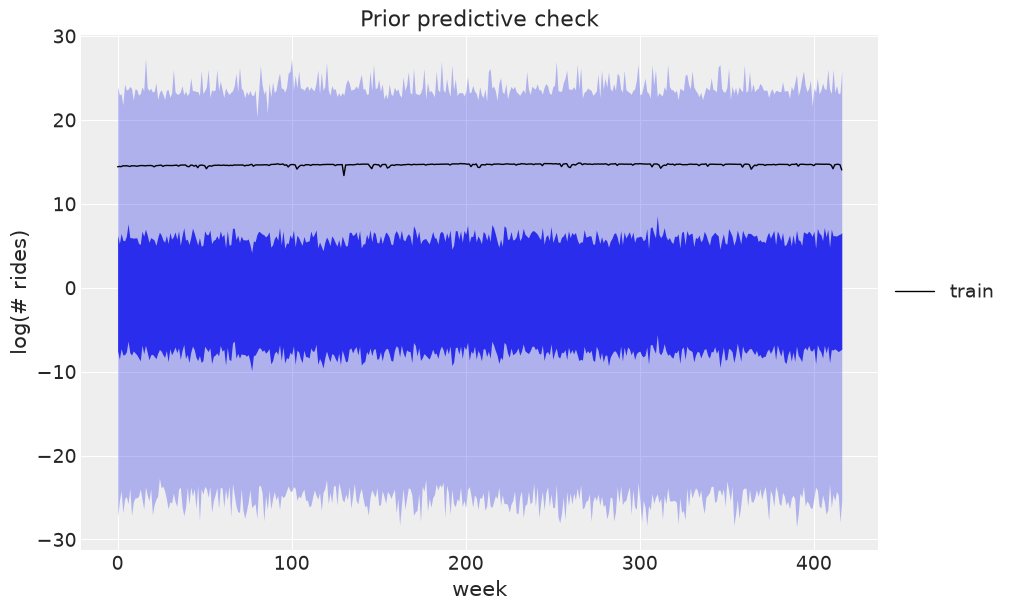

In [7]:
prior_model = build_model(model, y_train, covariates_train)
prior_idata = pm.sample_prior_predictive(
    draws=NUM_SAMPLES,
    model=prior_model,
    var_names=["obs"],
    random_seed=SEED,
)
attach_constant_data(
    prior_idata,
    name="week",
    values=y_train[TIME_DIM].values,
    dim=TIME_DIM,
)

prior_pc = az.plot_lm(
    prior_idata,
    y="obs",
    x="week",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = prior_pc.viz["figure"].item().axes[0]
ax.plot(y_train[TIME_DIM].values, y_train.values, color="black", lw=1, label="train")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Prior predictive check", xlabel="week", ylabel="log(# rides)")
plt.show()

## Inference with ADVI

`Forecaster` fits the model with PyMC variational inference. The non-centered random walk
keeps the high-dimensional weekly latent trajectory tractable for ADVI.


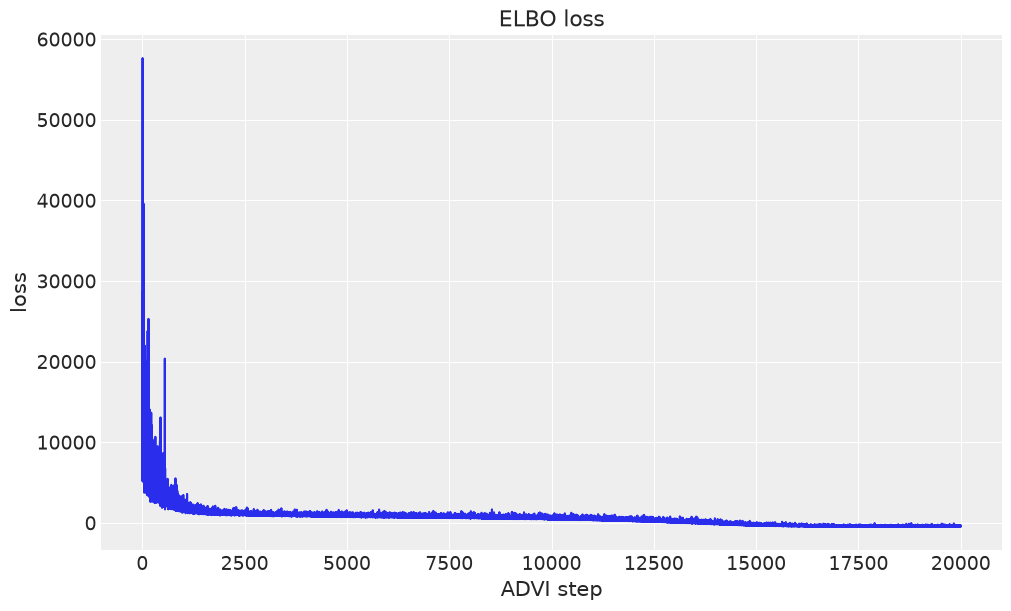

In [8]:
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optimizer=0.005,
    num_steps=NUM_STEPS,
    random_seed=SEED,
    fit_kwargs={"progressbar": False},
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="ADVI step", ylabel="loss")
plt.show()

## Posterior predictive check and forecast


In [9]:
train_pp_idata = forecaster.predict_in_sample(
    num_samples=NUM_SAMPLES,
    random_seed=SEED,
    progressbar=False,
)
forecast_idata = forecaster.forecast(
    covariates,
    num_samples=NUM_SAMPLES,
    random_seed=SEED,
    progressbar=False,
)
attach_constant_data(
    train_pp_idata,
    name="week",
    values=y_train[TIME_DIM].values,
    dim=TIME_DIM,
)

train_pp = train_pp_idata["posterior_predictive"]["obs"]
forecast = forecast_idata["predictions"]["forecast"]
forecast_lm_idata = lm_idata_from_forecast(
    forecast,
    y_test.rename({TIME_DIM: FUTURE_DIM}),
    x_name="week",
    x_values=y_test[TIME_DIM].values,
)

metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}
train_scores = evaluate_forecast(train_pp, y_train, metrics=metrics)
test_scores = evaluate_forecast(forecast, y_test.rename({TIME_DIM: FUTURE_DIM}), metrics=metrics)
print("train:", train_scores)
print("test: ", test_scores)

train: {'crps': 0.028555026889263202, 'coverage_50': 0.6378896882494005, 'coverage_94': 0.9640287769784173}
test:  {'crps': 0.03481793016505593, 'coverage_50': 0.6346153846153846, 'coverage_94': 0.9038461538461539}


## Forecast visualization


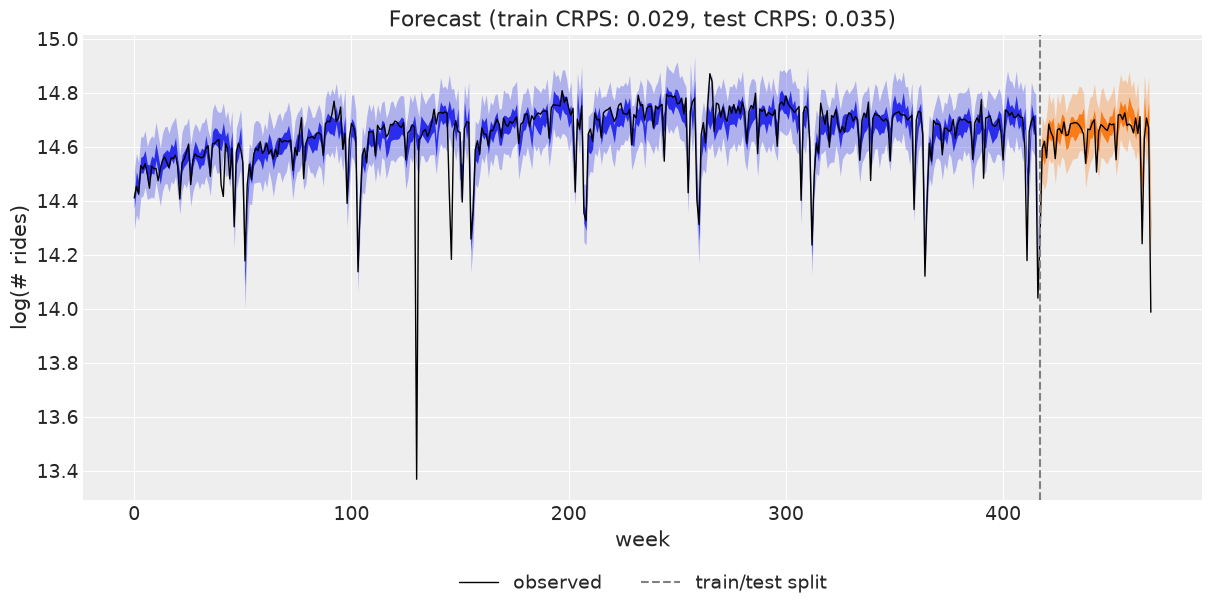

In [10]:
forecast_title = (
    f"Forecast (train CRPS: {train_scores['crps']:.3f}, test CRPS: {test_scores['crps']:.3f})"
)

pc = az.plot_lm(
    train_pp_idata,
    y="obs",
    x="week",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 6)},
)
az.plot_lm(
    forecast_lm_idata,
    y="obs",
    x="week",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
ax = pc.viz["figure"].item().axes[0]
ax.plot(y[TIME_DIM].values, y.values, color="black", lw=1, label="observed")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
ax.set(title=forecast_title, xlabel="week", ylabel="log(# rides)")
plt.show()

## Rolling-origin backtesting

The supported PyMC API refits expanding windows one fold at a time. Each fold forecasts
one year, advances one year, and keeps predictions labeled by their real week coordinates.
The upstream JAX-only vectorized backtest is intentionally omitted.


In [11]:
backtest_model = LocalLevelSeasonal()
results = backtest(
    y,
    covariates,
    backtest_model,
    metrics=metrics,
    test_window=52,
    stride=52,
    min_train_window=104,
    min_test_window=52,
    num_samples=BACKTEST_SAMPLES,
    eval_train=True,
    keep_predictions=True,
    forecaster_options={"optimizer": 0.005, "num_steps": NUM_STEPS},
    random_seed=SEED,
)
summary = results_to_dataframe(results)
summary

,t0,t1,t2,num_samples,train_walltime,test_walltime,crps,coverage_50,coverage_94,train_crps,train_coverage_50,train_coverage_94
0,0,104,156,500,72.068933,3.894191,0.068290,0.442308,0.942308,0.024918,0.855769,0.990385
1,0,156,208,500,57.775307,2.593398,0.040307,0.519231,0.923077,0.034820,0.743590,0.980769
2,0,208,260,500,43.358285,0.944961,0.030875,0.557692,0.980769,0.031596,0.716346,0.971154
3,0,260,312,500,75.345317,2.871415,0.025316,0.673077,0.980769,0.028461,0.726923,0.973077
4,0,312,364,500,50.631031,1.919438,0.029328,0.557692,0.980769,0.028013,0.692308,0.967949
5,0,364,416,500,13.027945,2.657666,0.037924,0.423077,0.903846,0.027974,0.689560,0.969780
6,0,416,468,500,29.529265,0.547134,0.037585,0.461538,0.903846,0.028298,0.653846,0.966346


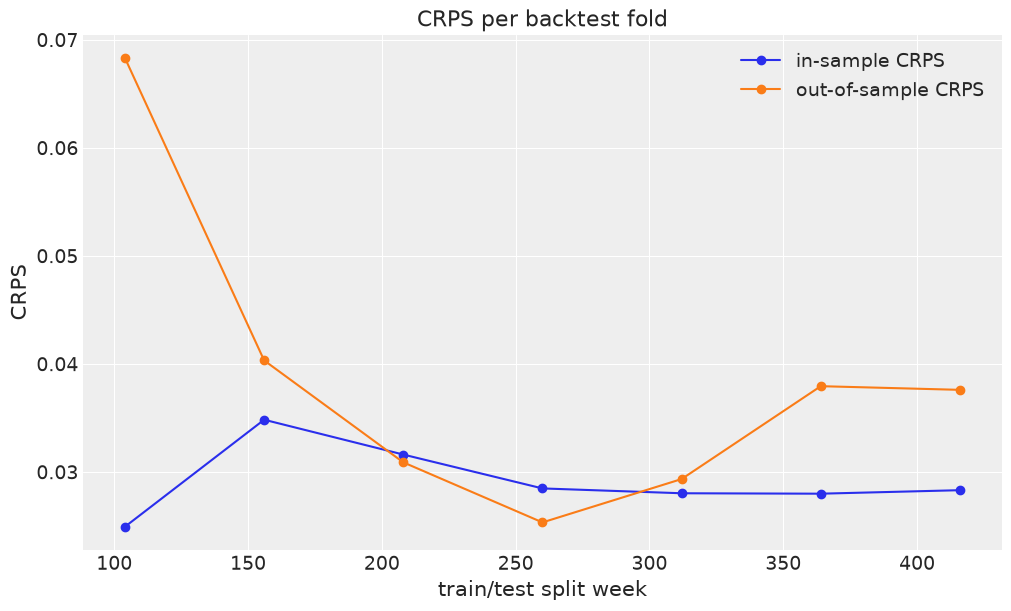

In [12]:
fig, ax = plt.subplots()
ax.plot(summary["t1"], summary["train_crps"], "o-", color="C0", label="in-sample CRPS")
ax.plot(summary["t1"], summary["crps"], "o-", color="C1", label="out-of-sample CRPS")
ax.legend()
ax.set(xlabel="train/test split week", ylabel="CRPS", title="CRPS per backtest fold")
plt.show()

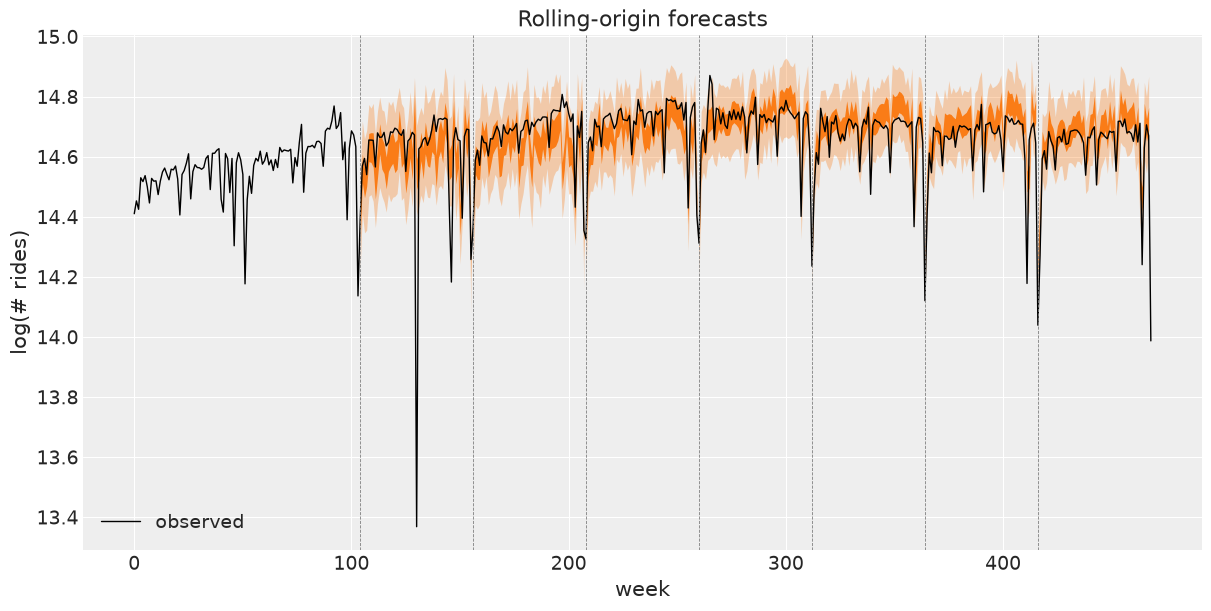

In [13]:
pc = None
for result in results:
    if result.prediction is None:
        continue
    truth = y.isel({TIME_DIM: slice(result.t1, result.t2)}).rename({TIME_DIM: FUTURE_DIM})
    fold_idata = lm_idata_from_forecast(
        result.prediction,
        truth,
        x_name="week",
        x_values=np.arange(result.t1, result.t2),
    )
    if pc is None:
        pc = az.plot_lm(
            fold_idata,
            y="obs",
            x="week",
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
            figure_kwargs={"figsize": (12, 6)},
        )
    else:
        az.plot_lm(
            fold_idata,
            y="obs",
            x="week",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
ax.plot(y[TIME_DIM].values, y.values, color="black", lw=1, label="observed")
for result in results:
    ax.axvline(result.t1, color="gray", ls="--", lw=0.6)
ax.legend(loc="lower left")
ax.set(title="Rolling-origin forecasts", xlabel="week", ylabel="log(# rides)")
plt.show()

## Functional API


In [14]:
def local_level_seasonal(h: Horizon, covariates: xr.DataArray) -> None:
    """Functional twin of ``LocalLevelSeasonal.model``."""
    bias = pm.Normal("bias", 0.0, 10.0)
    weight = pm.Normal("weight", 0.0, 0.1, dims="covariate")
    drift_scale = pm.LogNormal("drift_scale", -20.0, 5.0, initval=0.01)
    nu = pm.Gamma("nu", alpha=10.0, beta=2.0)
    sigma = pm.LogNormal("sigma", -5.0, 5.0, initval=0.05)

    drift_raw = time_series(
        h,
        "drift_raw",
        lambda name, dims: pm.Normal(name, 0.0, 1.0, dims=dims),
    )
    level = pt.cumsum(drift_raw * drift_scale)
    regression = pt.dot(covariates.values, weight)

    predict(
        h,
        lambda name, mu, dims, observed: pm.StudentT(
            name,
            nu=nu,
            mu=mu,
            sigma=sigma,
            dims=dims,
            observed=observed,
        ),
        bias + level + regression,
    )


oop_names = list(build_model(LocalLevelSeasonal(), y_train, covariates_train).named_vars)
functional_names = list(build_model(local_level_seasonal, y_train, covariates_train).named_vars)
print("same named variables:", oop_names == functional_names)
print(functional_names)

same named variables: True
['bias', 'weight', 'drift_scale', 'nu', 'sigma', 'drift_raw', 'obs']


## References

- Upstream NumPyro notebook: https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/forecasting_univariate.ipynb
- Pyro BART dataset mirror: https://github.com/pyro-ppl/datasets/tree/master/bart
- Juan Orduz, Univariate time series forecasting with NumPyro: https://juanitorduz.github.io/numpyro_forecasting-univariate/
